# Alessandro Picardi s0001182661

In [194]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Load the file data.csv, explore the data showing size and do some data exploration
## 2. Deal with null values, imputing the mean for numeric features and the string “unknown” for categorical features

In [221]:
filename = "data.csv"
sep = ","

df = pd.read_csv(filename, sep=sep)



In [196]:
display(df.head())

target = "class"

print(f"Dataset shape is {df.shape[0]}x{df.shape[1]}")

,Unnamed: 0,F00,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13,F14,class
0,0,NaN,0.430770,-0.609499,0.153154,-0.244014,1.515603,0.153154,0.950208,-0.533577,0.153154,-1.188635,0.117022,0,D,0.078747,1
1,1,NaN,0.926832,-1.232067,-2.397645,-2.147707,-0.907709,-2.397645,-3.431166,-0.851632,-2.397645,-0.614415,-0.641244,0,C,-0.277881,1
2,2,NaN,1.488724,1.732096,-0.247872,2.564819,-0.744121,-0.247872,-0.298340,-0.276540,-0.247872,1.395205,-0.290211,6,B,1.070634,0
3,3,NaN,0.476623,0.494316,0.585131,0.434526,-0.670993,0.585131,1.527264,0.370484,0.585131,-0.549108,0.009128,0,B,0.524313,1
4,4,NaN,1.873207,-0.399677,-1.768674,0.600575,0.274092,-1.768674,-2.147604,0.623849,-1.768674,-0.387073,-0.470436,3,D,0.411954,2


Dataset shape is 1000x17


In [197]:
display(df.describe(include="all"))

,Unnamed: 0,F00,F01,F02,F03,F04,F05,F06,F07,F08,F09,F10,F11,F12,F13,F14,class
count,1000.000000,50.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,B,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,269,NaN,NaN
mean,499.500000,0.190899,0.464389,0.024135,-0.090224,0.597048,-0.019323,-0.090224,-0.018502,0.017389,-0.090224,0.200876,0.019299,2.481000,NaN,0.163715,0.505000
std,288.819436,1.664705,1.253621,0.981668,1.047949,1.525925,1.007243,1.047949,1.493104,0.995193,1.047949,1.649333,1.015434,2.280974,NaN,0.534304,0.596935
min,0.000000,-4.768419,-3.839055,-3.678544,-2.900095,-5.303289,-3.411312,-2.900095,-4.593151,-2.870350,-2.900095,-4.562059,-3.375156,0.000000,NaN,-1.613691,0.000000
25%,249.750000,-0.653835,-0.261353,-0.643978,-0.847538,-0.302429,-0.635943,-0.847538,-1.070465,-0.650032,-0.847538,-1.024788,-0.657205,1.000000,NaN,-0.213942,0.000000
50%,499.500000,0.528885,0.554465,0.041989,-0.186079,0.754161,-0.019371,-0.186079,-0.046749,0.041118,-0.186079,0.166277,0.038561,2.000000,NaN,0.148387,0.000000
75%,749.250000,1.433727,1.289121,0.683684,0.565310,1.647466,0.618085,0.565310,1.049437,0.715784,0.565310,1.347618,0.660219,4.000000,NaN,0.523251,1.000000


F00 has less than 5% non-missing values, all other columns exhibit no missing values. Due to the small amount of data in this column, we decide to drop it altogether.

In [198]:
display(df.dtypes)

Unnamed: 0      int64
F00           float64
F01           float64
F02           float64
F03           float64
F04           float64
F05           float64
F06           float64
F07           float64
F08           float64
F09           float64
F10           float64
F11           float64
F12             int64
F13            object
F14           float64
class           int64
dtype: object

In [222]:
df.dropna(axis=1, how="any", inplace=True)

print(f"Dataset new shape is {df.shape[0]}x{df.shape[1]}")

Dataset new shape is 1000x16


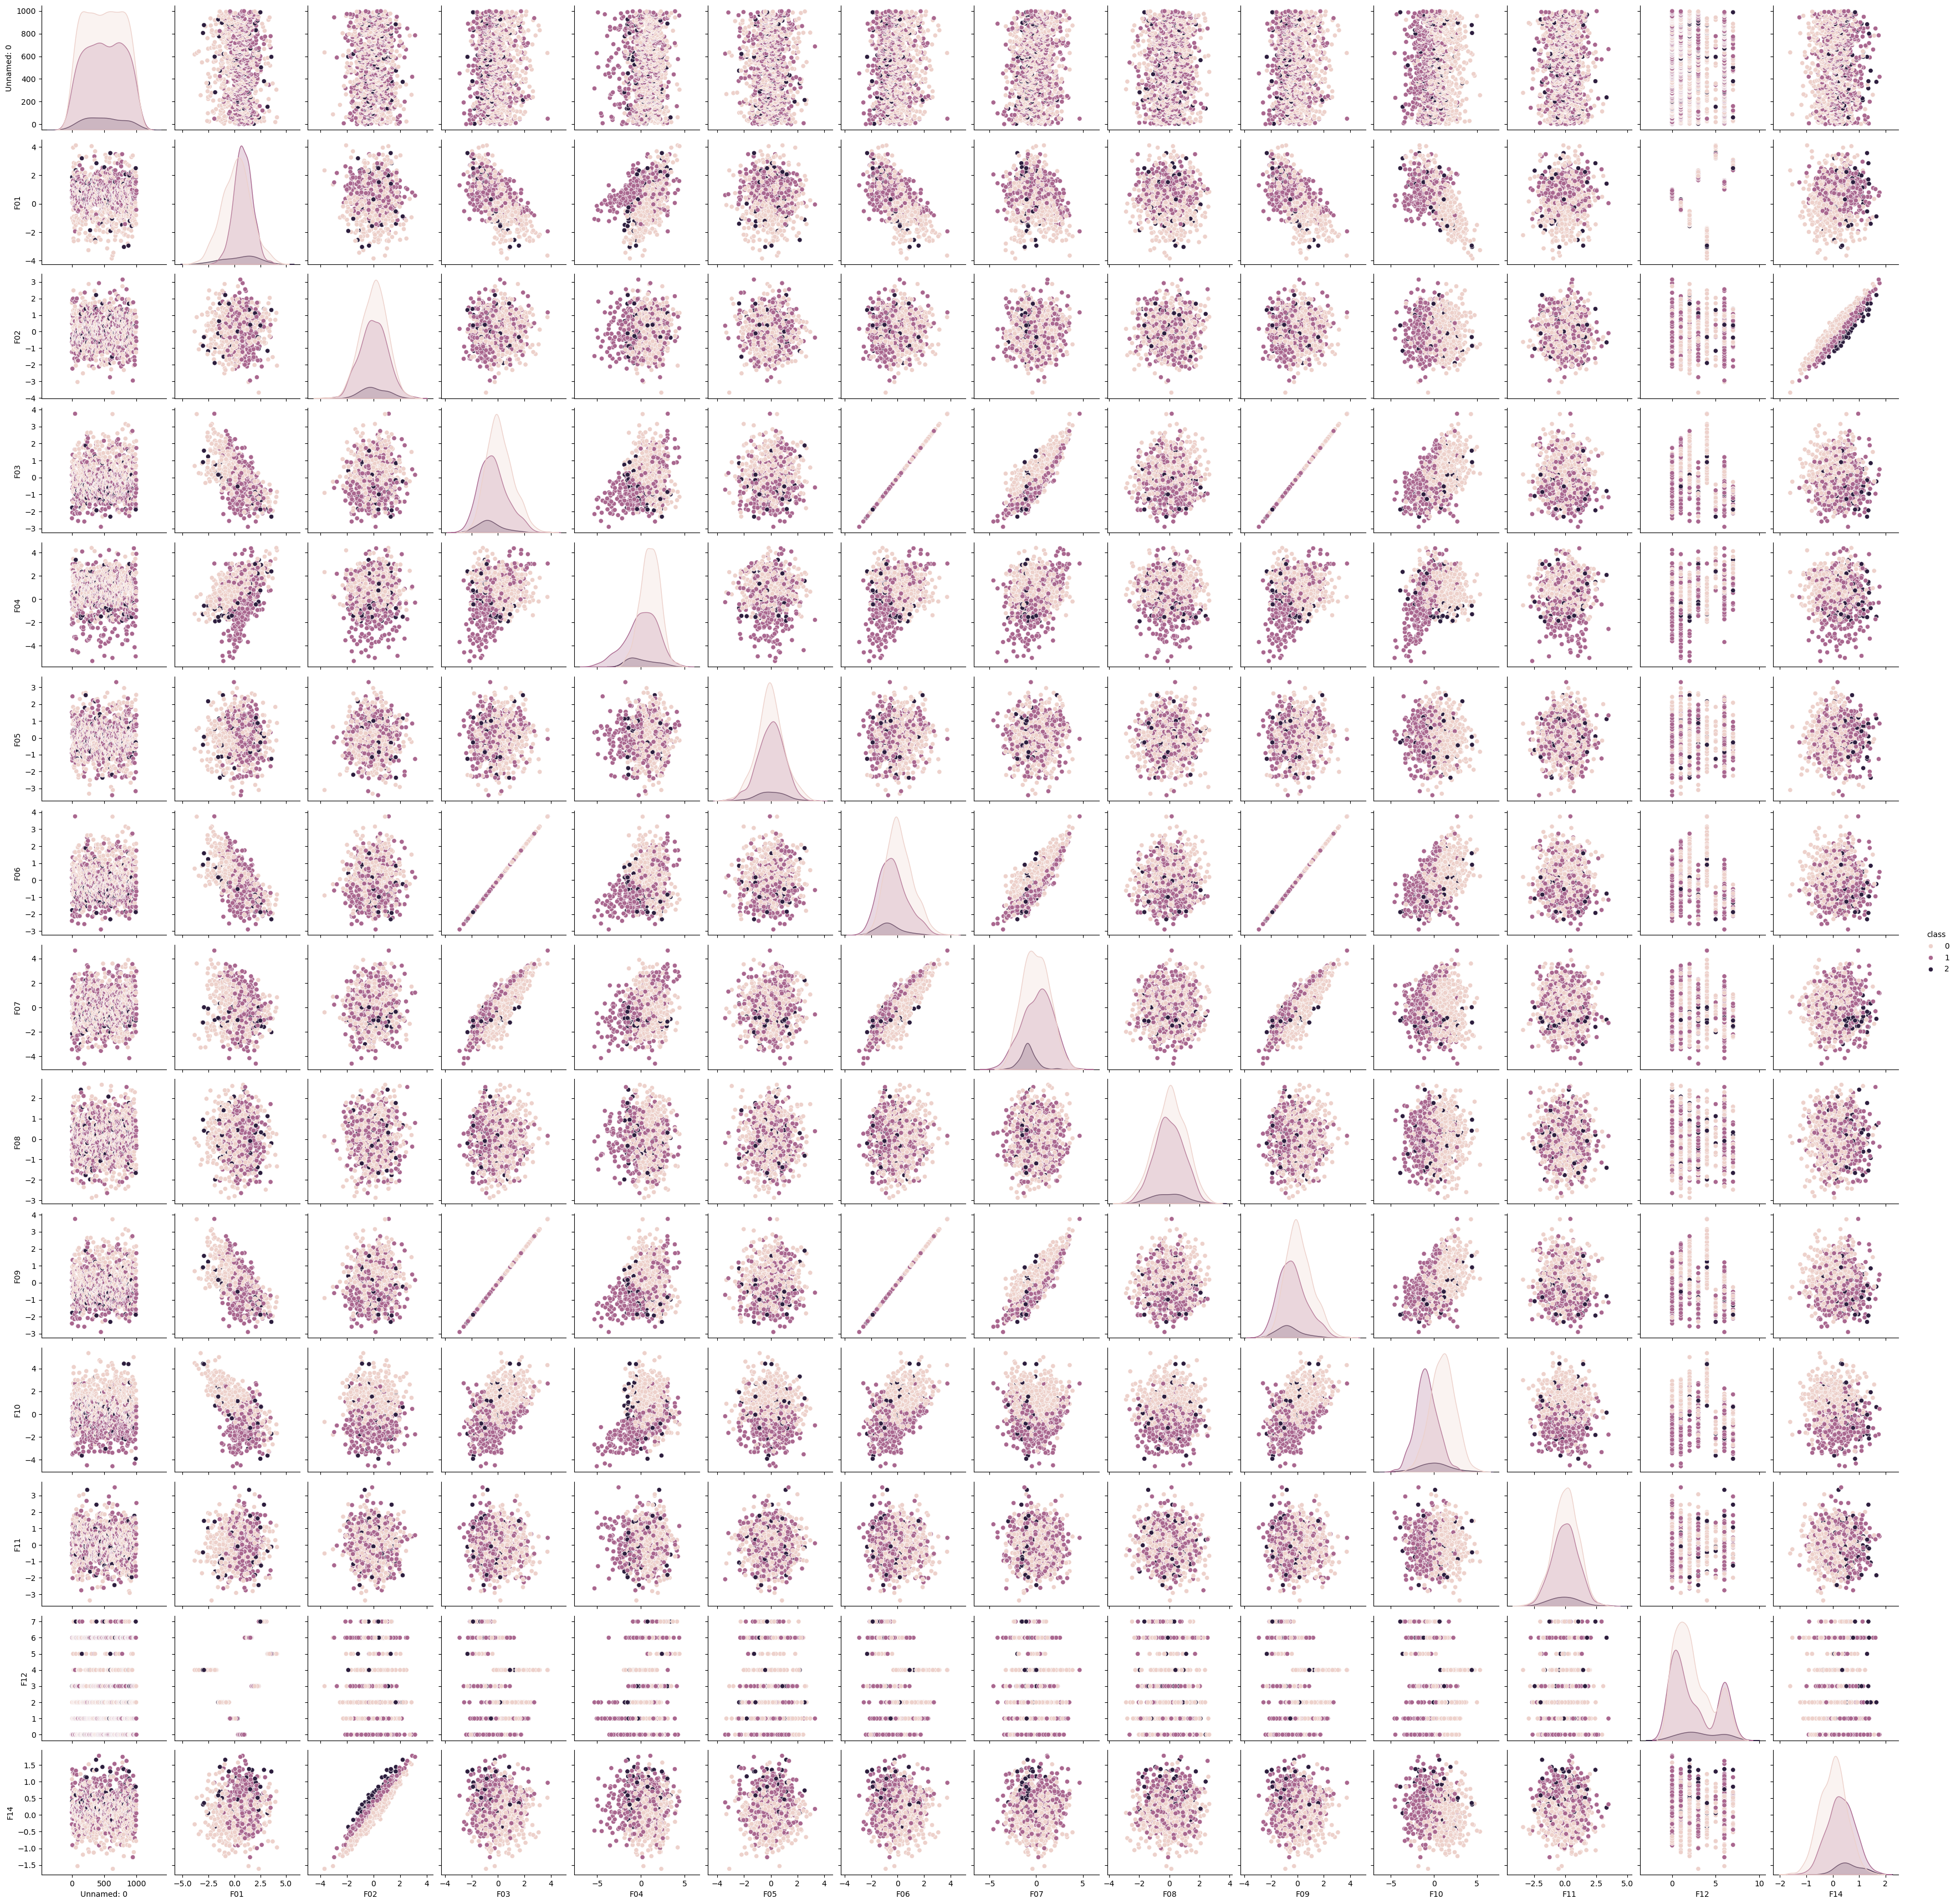

In [200]:
sns.pairplot(df, hue=target)
plt.show()

The data distributions appear well balanced and univariate for most features, regardless of the class.
Notable situations are exhibited by some features showing near perfect linear correlation, implying redundancy (F03, F06, F09 between themselves).

F13 doesn't appear in the classes of the pairplot, it being encoded nominally. Let's use OHE to make the data accesible by classifiers.

In [223]:
df["F13"].value_counts()

from sklearn.preprocessing import OneHotEncoder

OHE = OneHotEncoder()
F13 = OHE.fit_transform(pd.DataFrame(df["F13"]))

F13 = F13.toarray()

def map(x):
    if x<1:
        return False
    else:
        return True

colname = []

for i in np.arange(F13.shape[1]):
    colname.append("F13_"+str(i))

F13 = pd.DataFrame(F13, columns=colname)

F13 = F13.map(map)

display(F13)

df = pd.concat([df.drop("F13", axis=1), F13], axis=1)

,F13_0,F13_1,F13_2,F13_3
0,False,False,False,True
1,False,False,True,False
2,False,True,False,False
3,False,True,False,False
4,False,False,False,True
...,...,...,...,...
995,True,False,False,False
996,True,False,False,False
997,False,False,False,True
998,False,False,False,True


In [224]:
df[target].value_counts()

class
0    548
1    399
2     53
Name: count, dtype: int64

The target data is heavily unbalanced: this suggests using stratified k folds during the CV procedure, to make sure each classifier can train on some data belonging to each class.

## 3. train, optimize and test two classifier models of your choice, the optimization must be done with cross validation, optimize the f1-score_macro

## 4. show the result for both models, including the optimal hyperparameter values

In [257]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

random_state = 42

In [258]:
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

In [259]:
param_grid_DT = {"criterion": ["gini", "entropy"],
                 "max_depth": np.arange(2,11)}

DT = DecisionTreeClassifier(random_state=random_state)

score = "f1_macro"

grid_DT = GridSearchCV(estimator=DT, param_grid=param_grid_DT, scoring=[score, "accuracy"], refit=score, cv =skf, n_jobs=-1)

grid_DT.fit(X_train, y_train)

results_DT = pd.DataFrame(grid_DT.cv_results_)

display(results_DT.sort_values(by="rank_test_f1_macro", ascending=True).head(7))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,...,std_test_f1_macro,rank_test_f1_macro,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,split4_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy
16,0.015415,0.001016,0.004621,0.000320,entropy,9,"{'criterion': 'entropy', 'max_depth': 9}",0.686897,0.678758,0.658144,...,0.049612,1,0.76250,0.76875,0.78125,0.81875,0.70000,0.76625,0.038446,7
13,0.014407,0.000941,0.004920,0.000930,entropy,6,"{'criterion': 'entropy', 'max_depth': 6}",0.644466,0.690286,0.621928,...,0.028857,2,0.75625,0.77500,0.76875,0.81250,0.72500,0.76750,0.028339,6
17,0.014153,0.000870,0.003875,0.000701,entropy,10,"{'criterion': 'entropy', 'max_depth': 10}",0.673596,0.705490,0.621394,...,0.046369,3,0.75625,0.78125,0.77500,0.81250,0.69375,0.76375,0.039410,11
14,0.014478,0.000511,0.004311,0.000130,entropy,7,"{'criterion': 'entropy', 'max_depth': 7}",0.697649,0.663507,0.615301,...,0.045087,4,0.77500,0.76875,0.76875,0.81250,0.68125,0.76125,0.043193,12
15,0.017035,0.000707,0.004260,0.000345,entropy,8,"{'criterion': 'entropy', 'max_depth': 8}",0.696903,0.671956,0.604347,...,0.055703,5,0.77500,0.78125,0.75000,0.81875,0.68125,0.76125,0.045655,12
3,0.011389,0.001846,0.005911,0.001281,gini,5,"{'criterion': 'gini', 'max_depth': 5}",0.685783,0.575167,0.538391,...,0.048996,6,0.81875,0.76250,0.78125,0.79375,0.77500,0.78625,0.019121,2
8,0.012366,0.000383,0.004950,0.001212,gini,10,"{'criterion': 'gini', 'max_depth': 10}",0.644807,0.584895,0.516001,...,0.045758,7,0.76875,0.73125,0.68750,0.76875,0.76250,0.74375,0.031375,15


In [260]:
best_MD = grid_DT.best_estimator_.max_depth
best_C = grid_DT.best_estimator_.criterion
# To better narrow down our search

In [261]:

param_grid_RF = {"n_estimators": np.arange(10,101,20),
                 "max_depth": np.arange(-2,3)+best_MD,
                 "criterion": [best_C]}

RF = RandomForestClassifier(random_state=random_state)

score = "f1_macro"

grid_RF = GridSearchCV(estimator=RF, param_grid=param_grid_RF, scoring=[score, "accuracy"], refit=score, cv =skf, n_jobs=-1)

grid_RF.fit(X_train, y_train)

results_RF = pd.DataFrame(grid_RF.cv_results_)

display(results_RF.sort_values(by="rank_test_f1_macro", ascending=True).head(7))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_n_estimators,params,split0_test_f1_macro,split1_test_f1_macro,...,std_test_f1_macro,rank_test_f1_macro,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,split4_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy
11,0.128904,0.033796,0.007237,0.001159,entropy,9,30,"{'criterion': 'entropy', 'max_depth': 9, 'n_es...",0.642144,0.552401,...,0.030833,1,0.83750,0.81250,0.81875,0.86875,0.80625,0.82875,0.022569,12
6,0.109447,0.008199,0.006447,0.000159,entropy,8,30,"{'criterion': 'entropy', 'max_depth': 8, 'n_es...",0.556580,0.548234,...,0.058742,2,0.81875,0.80625,0.85000,0.84375,0.80625,0.82500,0.018540,16
16,0.108332,0.003781,0.006437,0.000179,entropy,10,30,"{'criterion': 'entropy', 'max_depth': 10, 'n_e...",0.562637,0.542413,...,0.046821,3,0.82500,0.80000,0.83750,0.84375,0.81250,0.82375,0.016008,18
12,0.214269,0.031289,0.011954,0.008622,entropy,9,50,"{'criterion': 'entropy', 'max_depth': 9, 'n_es...",0.575356,0.552401,...,0.033065,4,0.84375,0.81250,0.85000,0.85625,0.80625,0.83375,0.020387,3
14,0.377206,0.061685,0.013725,0.004982,entropy,9,90,"{'criterion': 'entropy', 'max_depth': 9, 'n_es...",0.570509,0.547719,...,0.037780,5,0.83750,0.80625,0.85625,0.85000,0.80625,0.83125,0.021287,6
13,0.289188,0.032006,0.011345,0.002895,entropy,9,70,"{'criterion': 'entropy', 'max_depth': 9, 'n_es...",0.561698,0.548234,...,0.037764,6,0.82500,0.80625,0.84375,0.85000,0.81875,0.82875,0.016105,12
21,0.117706,0.015715,0.007454,0.001140,entropy,11,30,"{'criterion': 'entropy', 'max_depth': 11, 'n_e...",0.567191,0.547152,...,0.033466,7,0.83125,0.80625,0.84375,0.86250,0.80625,0.83000,0.021794,9


DecisionTree Results:
              precision    recall  f1-score   support

           0       0.85      0.92      0.89       113
           1       0.81      0.68      0.74        76
           2       0.43      0.55      0.48        11

    accuracy                           0.81       200
   macro avg       0.70      0.72      0.70       200
weighted avg       0.81      0.81      0.81       200



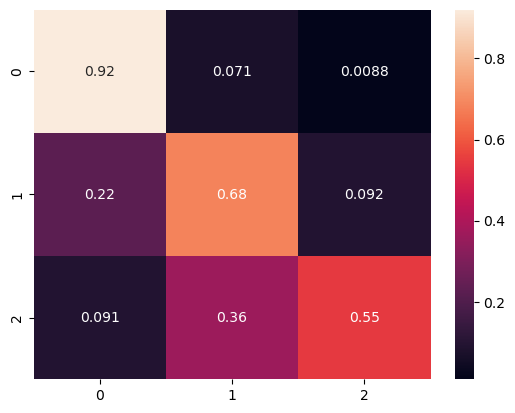

Random Forest Results:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       113
           1       0.81      0.80      0.81        76
           2       0.00      0.00      0.00        11

    accuracy                           0.82       200
   macro avg       0.55      0.57      0.56       200
weighted avg       0.78      0.82      0.80       200



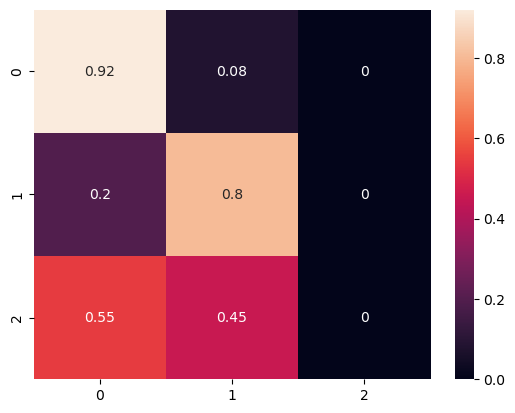

In [262]:
# Testing

print("DecisionTree Results:")

y_DT = grid_DT.predict(X_test)
cr_DT = classification_report(y_test, y_DT, zero_division=0)
print(cr_DT)

cm_DT = confusion_matrix(y_test, y_DT, normalize="true")

sns.heatmap(cm_DT, annot=True)
plt.show()

print("="*400)

print("Random Forest Results:")

y_RF = grid_RF.predict(X_test)
cr_RF = classification_report(y_test, y_RF, zero_division=0)
print(cr_RF)

cm_RF = confusion_matrix(y_test, y_RF, normalize="true")

sns.heatmap(cm_RF, annot=True)
plt.show()

We see that the bagging procedures employed by the Random Forest algorithm performe noticeably worse in classifying the minority classes, while performing better in the majority classes. This raises accuracy at the cost of the f1 macro score, the one we're trying to optimise. Going forward, we'll use Decision Trees.

## 5. repeat the experiment using the best model found in the previous steps and doing feature selection
## 6. show the results with the best hyperparameter values
## 7. comment the results of the two experiments

By the pairplot of the visualized data, we know that we can drop "F03" and "F06", since its data is already perfectly encoded in "F09".

In [282]:
df2 = df.drop(["F03","F06"], axis=1)

X = df2.drop(columns=target)
y = df2[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state)

In [283]:
param_grid_DT = {"criterion": ["gini", "entropy"],
                 "max_depth": np.arange(2,11)}

DT = DecisionTreeClassifier(random_state=random_state)

score = "f1_macro"

grid_DT = GridSearchCV(estimator=DT, param_grid=param_grid_DT, scoring=[score, "accuracy"], refit=score, cv =skf, n_jobs=-1)

grid_DT.fit(X_train, y_train)

results_DT = pd.DataFrame(grid_DT.cv_results_)

display(results_DT.sort_values(by="rank_test_f1_macro", ascending=True).head(7))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,...,std_test_f1_macro,rank_test_f1_macro,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,split4_test_accuracy,mean_test_accuracy,std_test_accuracy,rank_test_accuracy
15,0.013757,0.001247,0.004339,0.000262,entropy,8,"{'criterion': 'entropy', 'max_depth': 8}",0.711740,0.676726,0.617606,...,0.056716,1,0.78125,0.76875,0.76875,0.81875,0.69375,0.76625,0.040620,7
13,0.011800,0.000141,0.004754,0.000126,entropy,6,"{'criterion': 'entropy', 'max_depth': 6}",0.644466,0.676115,0.612024,...,0.034054,2,0.75625,0.77500,0.76250,0.79375,0.71875,0.76125,0.024812,10
16,0.014995,0.002366,0.004171,0.000485,entropy,9,"{'criterion': 'entropy', 'max_depth': 9}",0.698540,0.655092,0.604111,...,0.057713,3,0.76250,0.76875,0.75625,0.81875,0.66875,0.75500,0.048477,11
14,0.012547,0.000177,0.004399,0.000176,entropy,7,"{'criterion': 'entropy', 'max_depth': 7}",0.693481,0.658339,0.602519,...,0.062761,4,0.76875,0.76250,0.75000,0.81875,0.67500,0.75500,0.046334,11
17,0.013246,0.001185,0.003692,0.000429,entropy,10,"{'criterion': 'entropy', 'max_depth': 10}",0.698122,0.597532,0.600306,...,0.043952,5,0.77500,0.74375,0.75625,0.80625,0.68125,0.75250,0.041382,14
4,0.010124,0.000976,0.006861,0.001278,gini,6,"{'criterion': 'gini', 'max_depth': 6}",0.681483,0.579738,0.578020,...,0.042179,6,0.81250,0.76875,0.76875,0.75625,0.74375,0.77000,0.023184,5
12,0.010596,0.000248,0.004236,0.000307,entropy,5,"{'criterion': 'entropy', 'max_depth': 5}",0.606490,0.634404,0.600349,...,0.027041,7,0.79375,0.76875,0.75625,0.81250,0.71250,0.76875,0.034233,6


DecisionTree + Feature Selection Results:
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       113
           1       0.77      0.75      0.76        76
           2       0.40      0.55      0.46        11

    accuracy                           0.81       200
   macro avg       0.68      0.72      0.70       200
weighted avg       0.81      0.81      0.81       200



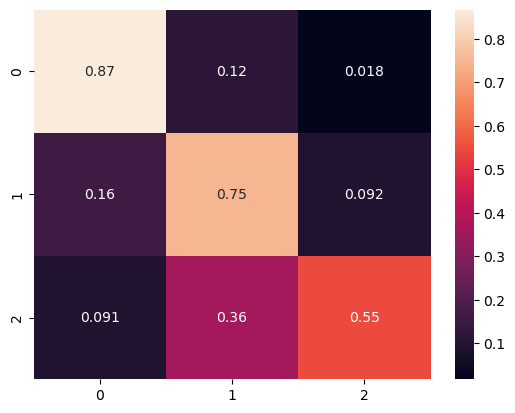

In [284]:
# Testing

print("DecisionTree + Feature Selection Results:")

y_DT = grid_DT.predict(X_test)
cr_DT = classification_report(y_test, y_DT, zero_division=0)
print(cr_DT)

cm_DT = confusion_matrix(y_test, y_DT, normalize="true")

sns.heatmap(cm_DT, annot=True)
plt.show()


This feature selection step does not drastically change the results: this is due to splits in the decision tree made on the basis of one of the pruned features causing the rest of the features to naturally cause a decreased information gain in subsequent steps.

If we had used another model, less robust to data correlation (E.G. Naive Bayes) this simple consideration could have resulted in vastly improved results.